# 03 — AR(1) credit-supply shock paths

**Ports**: `Code/MATLAB/Main.m` lines 267–280 (initial credit-expansion path) and `Code/MATLAB/MIT_transition.m` line 132 (unexpected-contraction path).

**Inputs**: `../output/params.npz`.

**Outputs (saved to `../output/shock_path.npz`)**:
- `TT` — horizon (200 quarters).
- `rho_shock` — shock persistence (0.98).
- `shock_b_agg` — `(TT,)` AR(1) credit-expansion path; the dashed *blue* line in Figure 1.
- `new_shock_b_agg` — `(TT,)` unexpected-contraction path back to SS; the solid *orange* line in Figure 1.
- `shock_start_t` — quarter at which the unexpected contraction kicks in (41).

**Why no model solution is needed**: both shock paths are pure analytical functions of structural parameters (`cur_acc`, `y_ss`, `rho_shock`, `b_agg_ss`). They live on the *forcing* side of the system, not the equilibrium side.

## Imports + load parameters

In [1]:
from pathlib import Path

import numpy as np

OUTPUT_DIR = Path('..') / 'output'
params_npz = np.load(OUTPUT_DIR / 'params.npz')

y_ss = float(params_npz['params__y_ss'])
b_agg_ss = float(params_npz['params__b_agg_ss'])

# `cur_acc` (current-account expansion / GDP in initial period) is a Main.m line 23 input,
# not in params.npz. Hard-coded here to match the MATLAB.
cur_acc = 0.074

print(f'y_ss      = {y_ss:.6f}')
print(f'b_agg_ss  = {b_agg_ss:.6f}  (calibrated NFA)')
print(f'cur_acc   = {cur_acc:.4f}')

y_ss      = 3.062548
b_agg_ss  = -4.343250  (calibrated NFA)
cur_acc   = 0.0740


## Path 1 — credit expansion (`shock_b_agg`)

Port of `Main.m` lines 267–277:

```matlab
TT          = 200;
rho_shock   = 0.98;
shock(1)    = -params.cur_acc * params.y_ss;
for s = 2:TT
    shock(s) = shock(s-1) - params.cur_acc * params.y_ss * rho_shock^(s-1);
end
```

This generates an **AR(1)-in-differences** path: the period-on-period change shrinks geometrically with $\rho_{\text{shock}} = 0.98$. The closed-form solution is
$$\text{shock}(s) = -\,\text{cur\_acc}\cdot y_{ss}\cdot \frac{1 - \rho_{\text{shock}}^{s}}{1 - \rho_{\text{shock}}},\quad s = 1,\dots,TT$$
but we use the recursive form to mirror MATLAB exactly.

In [2]:
TT = 200
rho_shock = 0.98

shock_b_agg = np.full(TT, np.nan)
shock_b_agg[0] = -cur_acc * y_ss
for s in range(1, TT):
    # MATLAB shock(s) = shock(s-1) - cur_acc*y_ss*rho_shock^(s-1)
    # In 1-indexed form, MATLAB s ∈ [2, TT] means the exponent is s-1.
    # In 0-indexed Python with the same iteration variable, exponent = s.
    shock_b_agg[s] = shock_b_agg[s - 1] - cur_acc * y_ss * rho_shock ** s

b_agg_ss_final = shock_b_agg[-1]
print(f'shock_b_agg[0]   = {shock_b_agg[0]:.6f}')
print(f'shock_b_agg[40]  = {shock_b_agg[40]:.6f}')
print(f'shock_b_agg[-1]  = {shock_b_agg[-1]:.6f}  (= b_agg_ss_final)')

shock_b_agg[0]   = -0.226629
shock_b_agg[40]  = -6.382014
shock_b_agg[-1]  = -11.132131  (= b_agg_ss_final)


## Path 2 — unexpected contraction (`new_shock_b_agg`)

Port of `MIT_transition.m` line 132:

```matlab
shock_start_t = 41;
temp = linspace(1, 0, TT)';
new_shock_b_agg = aggregates_calibrated.BGss + (shock_b_agg(shock_start_t-1) - aggregates_calibrated.BGss) * temp.^4;
```

where `aggregates_calibrated.BGss = b_agg_ss = target.nfa_gdp * y_ss` from notebook 02 (the calibrated steady-state NFA).

In words: at quarter `shock_start_t = 41`, foreign credit unexpectedly contracts and the economy travels back from the period-40 path value to the calibrated steady-state NFA along a quartic deceleration.

In [3]:
shock_start_t = 41                         # MATLAB 1-indexed; means "index 41" in MATLAB
shock_start_idx0 = shock_start_t - 1       # 0-indexed equivalent (40)

BGss = b_agg_ss  # = aggregates_calibrated.BGss in the MATLAB

temp = np.linspace(1.0, 0.0, TT)
new_shock_b_agg = BGss + (shock_b_agg[shock_start_idx0 - 1] - BGss) * temp ** 4

# unresolved: in MATLAB shock_b_agg(shock_start_t-1) is index 40 (1-indexed) = index 39 (0-indexed).
# That's the value of shock_b_agg one period BEFORE the contraction begins, which matches
# the explanatory text "travels back from the period-40 path value".
print(f'new_shock_b_agg[0]   = {new_shock_b_agg[0]:.6f}  (should equal shock_b_agg[{shock_start_idx0 - 1}] = {shock_b_agg[shock_start_idx0 - 1]:.6f})')
print(f'new_shock_b_agg[-1]  = {new_shock_b_agg[-1]:.6f}  (should equal BGss = {BGss:.6f})')

new_shock_b_agg[0]   = -6.281006  (should equal shock_b_agg[39] = -6.281006)
new_shock_b_agg[-1]  = -4.343250  (should equal BGss = -4.343250)


## Visualise both paths

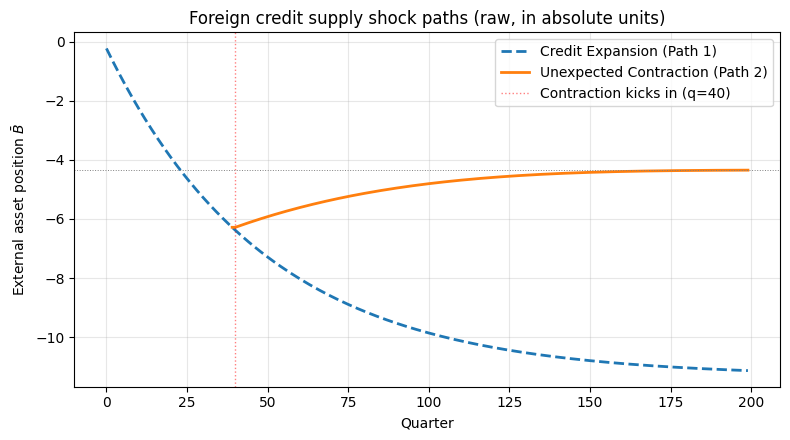

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(TT), shock_b_agg, label='Credit Expansion (Path 1)', lw=2, ls='--')
# Path 2 starts at quarter (shock_start_t - 1) = 40
x_path2 = np.arange(shock_start_idx0 - 1, TT)
y_path2 = np.concatenate([[shock_b_agg[shock_start_idx0 - 1]], new_shock_b_agg[: TT - shock_start_idx0]])
ax.plot(x_path2, y_path2, label='Unexpected Contraction (Path 2)', lw=2)
ax.axvline(shock_start_idx0, color='red', lw=1, ls=':', alpha=0.5, label=f'Contraction kicks in (q={shock_start_idx0})')
ax.axhline(BGss, color='gray', lw=0.7, ls=':')
ax.set_xlabel('Quarter')
ax.set_ylabel('External asset position $\\bar B$')
ax.set_title('Foreign credit supply shock paths (raw, in absolute units)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save outputs

In [5]:
out_path = OUTPUT_DIR / 'shock_path.npz'
np.savez(
    out_path,
    TT=TT,
    rho_shock=rho_shock,
    cur_acc=cur_acc,
    shock_b_agg=shock_b_agg,
    new_shock_b_agg=new_shock_b_agg,
    shock_start_t=shock_start_t,
    shock_start_idx0=shock_start_idx0,
    BGss=BGss,
    y_ss=y_ss,
)
print(f'Saved: {out_path.resolve()}')

Saved: /Users/siyingli/github/de-Ferra2020-kz/Code/Python/output/shock_path.npz
